# Resolução dos Exercícios — Escada da Recuperação na Web

**Disciplina:** Recuperação de Informação na Web e Redes Sociais  
**Aula 5:** Da API ao Selenium — degraus 1 ao 4

---

## Imports

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import urllib.parse
from datetime import datetime, timedelta

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('ok')

ok


---
## Exercício 1 — Expectativas do Focus para a Selic (Degrau 1 — API)

Recuperar via API Olinda as expectativas do Focus para a **Selic** e montar um DataFrame com os **10 meses mais recentes**.

In [2]:
def buscar_focus(indicador, meses=12, ano=None):
    if ano is None:
        ano = datetime.now().year
    base = ('https://olinda.bcb.gov.br/olinda/servico/Expectativas/versao/v1/odata/'
            'ExpectativasMercadoAnuais')
    filtro = f"Indicador eq '{indicador}' and baseCalculo eq 0 and DataReferencia eq '{ano}'"
    params = {
        '$top': str(meses * 24),
        '$format': 'json',
        '$orderby': 'Data desc',
        '$filter': filtro,
        '$select': 'Indicador,Data,DataReferencia,Media,Mediana,DesvioPadrao',
    }
    url = base + '?' + urllib.parse.urlencode(params, quote_via=urllib.parse.quote)
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.DataFrame(resp.json().get('value', []))
    if df.empty:
        return df
    df['Data'] = pd.to_datetime(df['Data'])
    df['mes'] = df['Data'].dt.to_period('M')
    df = df.sort_values('Data').groupby('mes', as_index=False).last()
    df = df.tail(meses).reset_index(drop=True)
    df['mes'] = df['mes'].dt.to_timestamp()
    return df

In [3]:
df_selic = buscar_focus('Selic', meses=10)

print('Indicador :', df_selic['Indicador'].iloc[0])
print('Ano-ref   :', df_selic['DataReferencia'].iloc[0])
print('Registros :', len(df_selic), 'meses')
print('Período   :', df_selic['mes'].min().strftime('%b/%Y'),
      'a', df_selic['mes'].max().strftime('%b/%Y'))
print()
df_selic[['mes', 'Mediana', 'Media', 'DesvioPadrao']]

Indicador : Selic
Ano-ref   : 2026
Registros : 10 meses
Período   : Oct/2025 a Jul/2026



,mes,Mediana,Media,DesvioPadrao
0,2025-10-01,12.25,12.1750,0.6779
1,2025-11-01,12.00,12.1405,0.5770
2,2025-12-01,12.25,12.2225,0.6313
3,2026-01-01,12.25,12.2617,0.5988
4,2026-02-01,12.00,12.1567,0.5587
5,2026-03-01,12.50,12.5453,0.5851
6,2026-04-01,13.00,12.9694,0.5753
7,2026-05-01,13.25,13.2962,0.5171
8,2026-06-01,14.00,13.8594,0.3735
9,2026-07-01,14.00,13.8503,0.3650


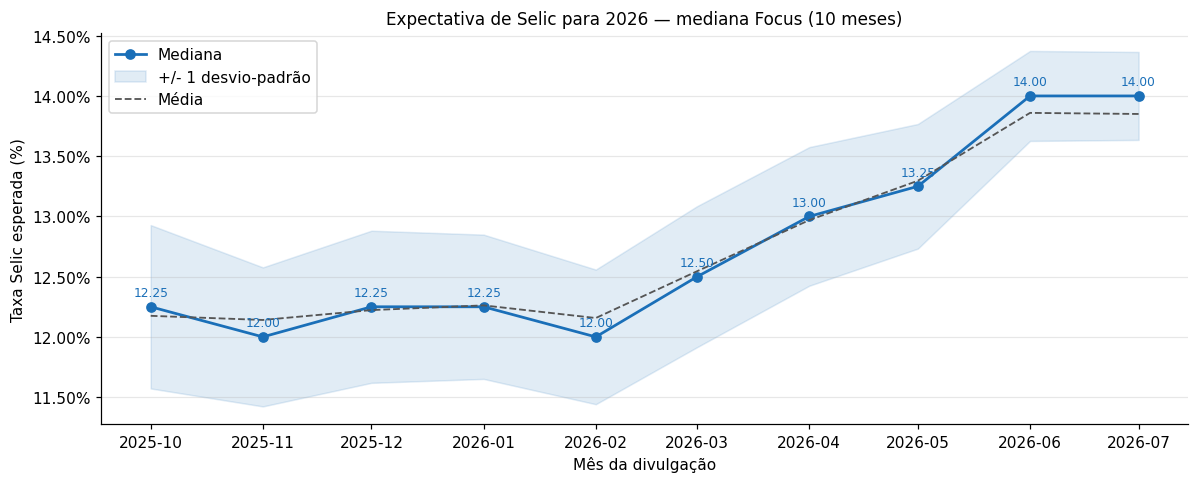

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(df_selic['mes'], df_selic['Mediana'],
        marker='o', color='#1A6FB8', linewidth=1.8, label='Mediana')
ax.fill_between(df_selic['mes'],
                df_selic['Mediana'] - df_selic['DesvioPadrao'],
                df_selic['Mediana'] + df_selic['DesvioPadrao'],
                color='#1A6FB8', alpha=0.13, label='+/- 1 desvio-padrão')
ax.plot(df_selic['mes'], df_selic['Media'],
        linestyle='--', color='#555', linewidth=1.2, label='Média')

for _, row in df_selic.iterrows():
    ax.annotate(f"{row['Mediana']:.2f}",
                xy=(row['mes'], row['Mediana']),
                xytext=(0, 7), textcoords='offset points',
                ha='center', fontsize=8, color='#1A6FB8')

ano_ref = df_selic['DataReferencia'].iloc[0]
ax.set_title(f'Expectativa de Selic para {ano_ref} — mediana Focus (10 meses)', fontsize=11)
ax.set_xlabel('Mês da divulgação')
ax.set_ylabel('Taxa Selic esperada (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.savefig('ex1_selic_focus.png', dpi=120, bbox_inches='tight')
plt.show()

### Por que a API é melhor do que raspar o boletim Focus?

O boletim Focus sai como PDF e a página HTML muda de estrutura com frequência — qualquer ajuste no layout quebra o scraper. Pela API Olinda os dados chegam em JSON estruturado direto da fonte, sem depender de como a página está montada. Outro ponto: fazer requisições repetidas a uma página web gera carga no servidor sem necessidade, enquanto a API existe exatamente para esse tipo de acesso.

---

## Exercício 2 — Câmbio PTAX vs. Expectativa do Focus (Degrau 1)

Buscar o câmbio **PTAX (venda)** e as **expectativas Focus para o Câmbio** no ano de **2025**, visualizar cada distribuição e comparar as duas séries.

In [5]:
def buscar_ptax(ano=2025):
    ini = datetime(ano, 1, 1)
    fim = min(datetime(ano, 12, 31), datetime.now())
    base = ('https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/'
            'CotacaoDolarPeriodo(dataInicial=@di,dataFinalCotacao=@df)')
    params = {
        '@di': f"'{ini.strftime('%m-%d-%Y')}'",
        '@df': f"'{fim.strftime('%m-%d-%Y')}'",
        '$format': 'json',
        '$select': 'cotacaoCompra,cotacaoVenda,dataHoraCotacao',
    }
    resp = requests.get(base, params=params, timeout=30)
    resp.raise_for_status()
    df = pd.DataFrame(resp.json().get('value', []))
    df['dataHoraCotacao'] = pd.to_datetime(df['dataHoraCotacao'])
    return df.sort_values('dataHoraCotacao').reset_index(drop=True)

df_ptax = buscar_ptax(2025)
print(f'PTAX 2025: {len(df_ptax)} cotações diárias')
print(f'Período  : {df_ptax["dataHoraCotacao"].min():%d/%m/%Y} '
      f'a {df_ptax["dataHoraCotacao"].max():%d/%m/%Y}')
print(f'Min/Max  : R$ {df_ptax["cotacaoVenda"].min():.4f} / '
      f'R$ {df_ptax["cotacaoVenda"].max():.4f}')
df_ptax[['dataHoraCotacao','cotacaoVenda']].head()

PTAX 2025: 253 cotações diárias
Período  : 02/01/2025 a 31/12/2025
Min/Max  : R$ 5.2729 / R$ 6.2086


,dataHoraCotacao,cotacaoVenda
0,2025-01-02 13:09:42.489,6.2086
1,2025-01-03 13:07:30.503,6.1563
2,2025-01-06 13:06:28.533,6.1119
3,2025-01-07 13:03:28.766,6.0741
4,2025-01-08 13:08:59.784,6.1321


In [6]:
df_cambio = buscar_focus('Câmbio', meses=24, ano=2025)
print(f'Focus Câmbio 2025: {len(df_cambio)} meses')
print(f'Mediana min/max  : {df_cambio["Mediana"].min():.2f} / '
      f'{df_cambio["Mediana"].max():.2f}')
df_cambio[['mes','Mediana','Media','DesvioPadrao']].head()

Focus Câmbio 2025: 24 meses
Mediana min/max  : 5.00 / 6.00


,mes,Mediana,Media,DesvioPadrao
0,2024-01-01,5.00,4.9799,0.1840
1,2024-02-01,5.00,4.9647,0.1831
2,2024-03-01,5.00,4.9833,0.1620
3,2024-04-01,5.05,5.0603,0.1420
4,2024-05-01,5.05,5.0665,0.1787


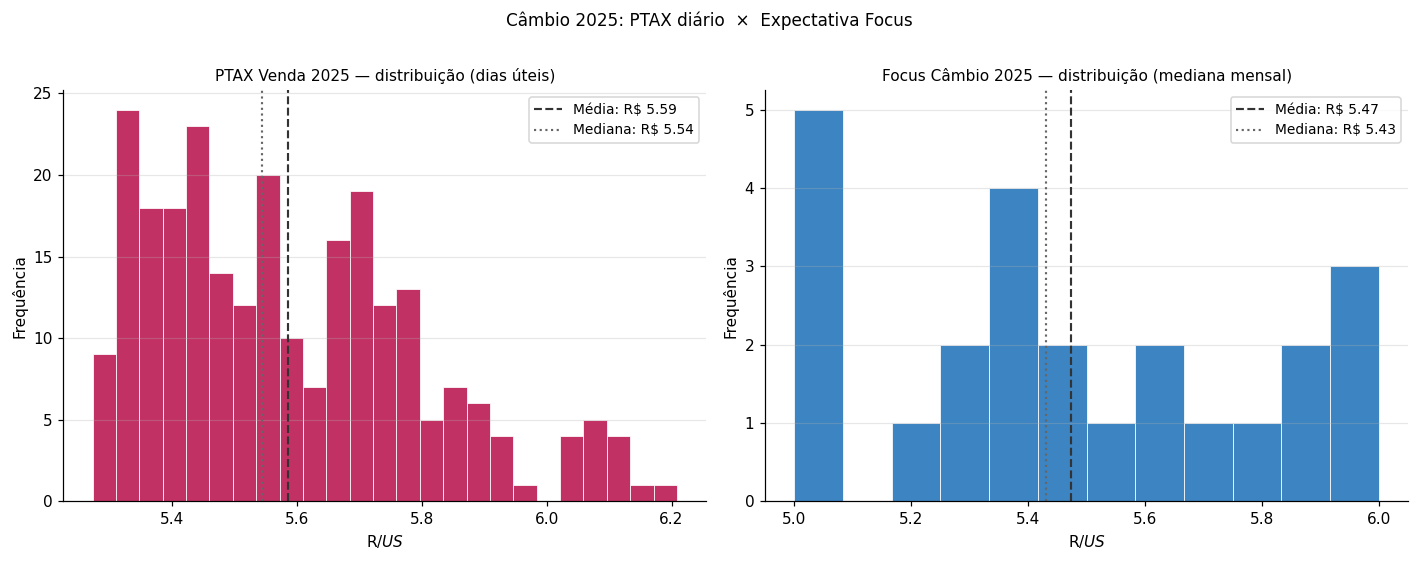

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax1.hist(df_ptax['cotacaoVenda'], bins=25, color='#B80D48',
         edgecolor='white', linewidth=0.6, alpha=0.85)
ax1.axvline(df_ptax['cotacaoVenda'].mean(), color='#333', linestyle='--',
            linewidth=1.4, label=f'Média: R$ {df_ptax["cotacaoVenda"].mean():.2f}')
ax1.axvline(df_ptax['cotacaoVenda'].median(), color='#666', linestyle=':',
            linewidth=1.4, label=f'Mediana: R$ {df_ptax["cotacaoVenda"].median():.2f}')
ax1.set_title('PTAX Venda 2025 — distribuição (dias úteis)', fontsize=10)
ax1.set_xlabel('R$ / US$'); ax1.set_ylabel('Frequência'); ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.hist(df_cambio['Mediana'], bins=12, color='#1A6FB8',
         edgecolor='white', linewidth=0.6, alpha=0.85)
ax2.axvline(df_cambio['Mediana'].mean(), color='#333', linestyle='--',
            linewidth=1.4, label=f'Média: R$ {df_cambio["Mediana"].mean():.2f}')
ax2.axvline(df_cambio['Mediana'].median(), color='#666', linestyle=':',
            linewidth=1.4, label=f'Mediana: R$ {df_cambio["Mediana"].median():.2f}')
ax2.set_title('Focus Câmbio 2025 — distribuição (mediana mensal)', fontsize=10)
ax2.set_xlabel('R$ / US$'); ax2.set_ylabel('Frequência'); ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Câmbio 2025: PTAX diário  ×  Expectativa Focus', fontsize=11, y=1.01)
fig.tight_layout()
plt.savefig('ex2_cambio_comparativo.png', dpi=120, bbox_inches='tight')
plt.show()

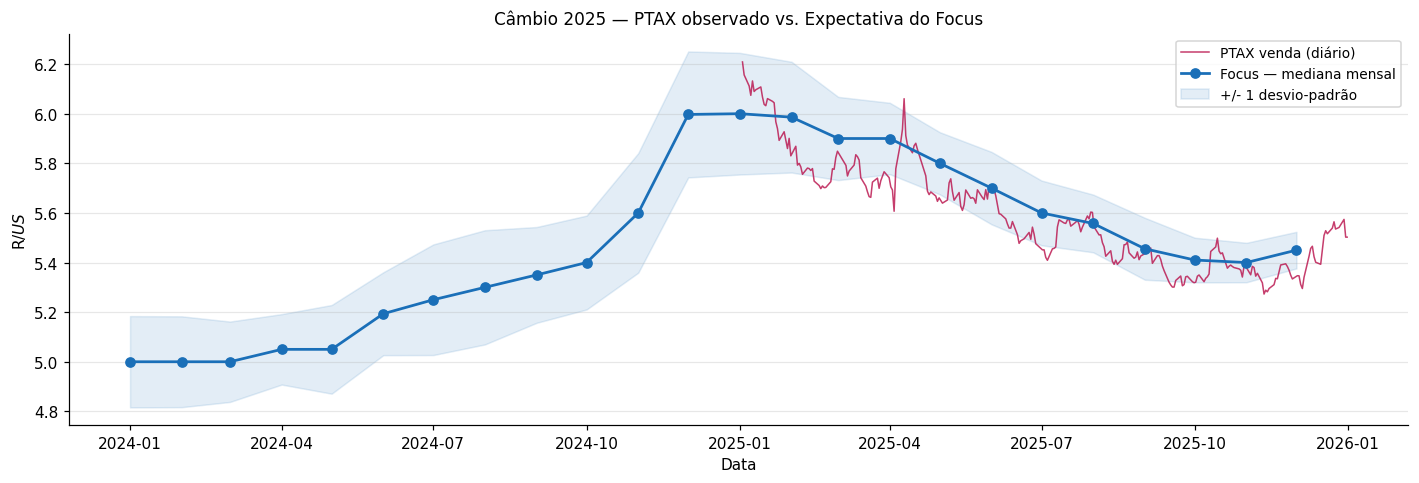

In [8]:
fig, ax = plt.subplots(figsize=(13, 4.5))

ax.plot(df_ptax['dataHoraCotacao'], df_ptax['cotacaoVenda'],
        color='#B80D48', linewidth=1.0, alpha=0.8, label='PTAX venda (diário)')
ax.plot(df_cambio['mes'], df_cambio['Mediana'],
        color='#1A6FB8', marker='o', linewidth=1.8, label='Focus — mediana mensal')
ax.fill_between(df_cambio['mes'],
                df_cambio['Mediana'] - df_cambio['DesvioPadrao'],
                df_cambio['Mediana'] + df_cambio['DesvioPadrao'],
                color='#1A6FB8', alpha=0.12, label='+/- 1 desvio-padrão')

ax.set_title('Câmbio 2025 — PTAX observado vs. Expectativa do Focus', fontsize=11)
ax.set_xlabel('Data'); ax.set_ylabel('R$ / US$')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.savefig('ex2_cambio_serie.png', dpi=120, bbox_inches='tight')
plt.show()

### Análise comparativa

A PTAX é a cotação diária realizada; a mediana Focus é a expectativa mensal do mercado para o câmbio no fim do ano. Em 2025 o dólar subiu de forma consistente e as projeções do Focus foram revisadas para cima junto — o gráfico de série temporal deixa essa relação visível.

---

## Exercício 3 — Qual degrau? (Julgamento)

Para cada cenário, identificar o degrau correto da escada.

**a) Preço de fechamento diário de uma ação — corretora tem endpoint REST documentado.**  
Degrau 1 (API). Tem endpoint documentado e mantido pela fonte — não precisa ir além.

**b) Texto de uma norma que aparece só depois que o JavaScript do visualizador carrega.**  
Degrau 4 (Selenium). O HTML chega vazio; o conteúdo só existe depois que o JS roda no navegador.

**c) Tabela de indicadores que só aparece após preencher um formulário e clicar em enviar.**  
Degrau 4 (Selenium com interação). Precisa preencher campo e clicar; só o Selenium faz isso.

**d) Série histórica de IPCA que o IBGE disponibiliza como CSV para download.**  
Degrau 2 (dados abertos). O IBGE já entrega o arquivo; só baixar o CSV.

**e) Notícias listadas no HTML de um portal, sem API, já presentes na resposta do servidor.**  
Degrau 3 (scraping estático). O conteúdo está no HTML; requests + BeautifulSoup resolvem.

---

## Exercício 4 — Antes de raspar, leia os termos (Ética)

Verificando `economia.uol.com.br` antes de usar o Selenium.

In [ ]:
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

ROBOTS_CACHE = """
# economia.uol.com.br/robots.txt — obtido manualmente em 06/07/2026
User-agent: *
Disallow: /dev/
Disallow: /busca?q=
Disallow: /*.jhtm
Disallow: /next=

User-agent: DataForSeoBot
Disallow: /

User-agent: Diffbot
Disallow: /

User-agent: FacebookBot
Disallow: /

User-agent: Twitterbot
Disallow: /

Sitemap: https://economia.uol.com.br/sitemap.xml
"""

headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/125.0.0.0 Safari/537.36'
    )
}

try:
    r = requests.get('https://economia.uol.com.br/robots.txt',
                     headers=headers, timeout=15, verify=False)
    conteudo = r.text if r.status_code == 200 else ROBOTS_CACHE
    fonte = 'ao vivo' if r.status_code == 200 else f'HTTP {r.status_code} — usando cache'
except Exception as e:
    conteudo = ROBOTS_CACHE
    fonte = f'erro ({e.__class__.__name__}) — usando cache'

print(f'Fonte: {fonte}')
print(conteudo[:1500])

Fonte: HTTP 403 — usando cache

# economia.uol.com.br/robots.txt — obtido manualmente em 06/07/2026
User-agent: *
Disallow: /dev/
Disallow: /busca?q=
Disallow: /*.jhtm
Disallow: /next=

User-agent: DataForSeoBot
Disallow: /

User-agent: Diffbot
Disallow: /

User-agent: FacebookBot
Disallow: /

User-agent: Twitterbot
Disallow: /

Sitemap: https://economia.uol.com.br/sitemap.xml



### Análise

**Existe API ou dados abertos que tornam o scraping desnecessário?**  
Para câmbio e indicadores financeiros, sim. O UOL exibe dados que já estão disponíveis pela API Olinda do Banco Central — não faz sentido raspar o portal quando a fonte original entrega os mesmos números em JSON. Para notícias não há API; o RSS seria o passo seguinte antes de partir para o Selenium.

**O que dizem os Termos de Uso sobre acesso automatizado?**  
O UOL proíbe usos que gerem carga excessiva nos servidores e não autoriza acesso automatizado. Scraping não está liberado.

**O robots.txt permite as rotas pretendidas?**  
Para `User-agent: *` só `/dev/`, `/busca?q=`, `/*.jhtm` e `/next=` estão bloqueados; rotas de notícias não aparecem. Mas o UOL bloqueia por completo Diffbot, DataForSeoBot e outros coletores — o site claramente não quer ser raspado.

**Se o robots.txt permite, mas os Termos de Uso proíbem — o que prevalece?**  
Os Termos de Uso. O `robots.txt` orienta indexadores mas não tem força contratual. Os Termos são um acordo com o usuário; desrespeitar é problema do coletor.

---

## Exercício 5 — Abordagem de monitoramento (Degrau 4)

Para cada necessidade, indicar a abordagem mais adequada: **snapshot periódico**, **detecção de mudança** ou **sessão ao vivo**.

**a) Reconstruir a série temporal completa do dólar minuto a minuto durante o pregão.**  
Snapshot periódico. A ideia é gravar cada leitura com o horário, mesmo que o valor não tenha mudado — o histórico completo é o resultado esperado.

**b) Observar o número piscando em tempo real numa página que se atualiza sozinha.**  
Sessão ao vivo. O navegador fica aberto e relê o elemento continuamente; não precisa salvar tudo, só acompanhar o valor enquanto muda.

**c) Disparar um alerta quando a cotação cruzar R$ 5,50.**  
Detecção de mudança. Verifica periodicamente e só age quando o valor cruza o limiar; gasta menos armazenamento que o snapshot e é mais direto que manter sessão ao vivo.

| Necessidade | Abordagem |
|---|---|
| Série temporal completa | Snapshot periódico |
| Acompanhar em tempo real | Sessão ao vivo |
| Alertar ao cruzar limiar | Detecção de mudança |
